In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

<h1>CUP - KNN</h1>
<p>Exploring the cup dataset with KNN Regressor.</p>
<hr/>

In [2]:
import importlib
import numpy as np
import cross_common as cr
import cup_common as cc
import knn_common as kc
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from cross_common import MEE,MSE,RMSE,MAE,R2,LOSS


In [3]:
importlib.reload(cc)
importlib.reload(kc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [4]:
# The common fold strategy used trough all models
outer_cv = cr.common_fold_strategy(False)
default_krange = list(range(1, 41, 2)) # <-- it means [1, 3, 5,..., 39]
default_metric = cr.MEE
scoring = cr.Scoring(default_metric)
grid_scoring = scoring.grid_scoring #cr.common_scoring(default_metric)
scaler = RobustScaler()

default_pipe = Pipeline([
    ("scaler", scaler),
    ("model", KNeighborsRegressor())
])

#gamma_values = np.logspace(-2, 1, 5)
#gamma_values = np.logspace(0, 2, 5)
gamma_values = np.logspace(1, 1.8, 6)


default_param_grid = [
    # { # Custom functions
    #     "model__n_neighbors": default_krange,
    #     "model__weights": [kc.GaussianWeights(g) for g in gamma_values],
    #     "model__algorithm": ["brute"], # <-- as for sklearn documentation we have to use 'brute'
    #     "model__p": [1, 2],          # 1=Manhattan, 2=Euclidean
    #     "model__metric": ["minkowski"]
    # },
    { # Standard sklearn way
        "scaler": [
            StandardScaler(),
            RobustScaler(),
        ],
        "model__n_neighbors": default_krange,
        "model__weights": ["uniform"],
        "model__algorithm": ["auto"],
        "model__p": [1, 2],          # 1=Manhattan, 2=Euclidean
        "model__metric": ["minkowski"]
    }
]

# --- The metrics to compute in training ---
metrics_dict = {
    MEE: (cr.mee, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    R2: (cr.r2,max)
}
the_metrics = metrics_dict.keys()
# ------------------------------------------


In [5]:
print(grid_scoring)

make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')


<h3>Data Loading</h3>

In [6]:
df_train, df_test = cc.load_set()

# The train set used for model selection
X_ts, y_ts = cc.prepare_dataset(df_test)

# Split the 500 labelled samples:
# - 80% development set for model selection and cross-validation
# - 20% internal test set for the final independent assessment
(
    X_tr, y_tr, # The train set
    X_internal_ts, y_internal_ts # The internal test set
 ) = (
    # by default 'prepare for hold out' split into 80% - 20%
    cc.prepare_dataset_for_hold_out(df_train,random_state=cc.INTERNAL_TEST_RANDOM_STATE)
)

features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,400,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [7]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.44424819946289
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-34.0255928  -36.09343338 -35.34489059 -35.34389114 -36.41343307]


<h3>Best Model</h3>

In [8]:
importlib.reload(cr)

gs = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=grid_scoring,
    cv=outer_cv,
    n_jobs=-1,
    return_train_score=True
)

gs.fit(X_tr, y_tr)
best_estimator = gs.best_estimator_
best_base_model, best_base_params = cr.extract_best_pipeline_metrics_from_grid(gs)
cr.grid_introspection(gs)

Grid summary
----------------------------------------
Total model explored: 80  splits: 5
Best params: {'model__algorithm': 'auto', 'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'uniform', 'scaler': StandardScaler()}
Best score: -16.322267723083495
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsRegressor(n_neighbors=3))])


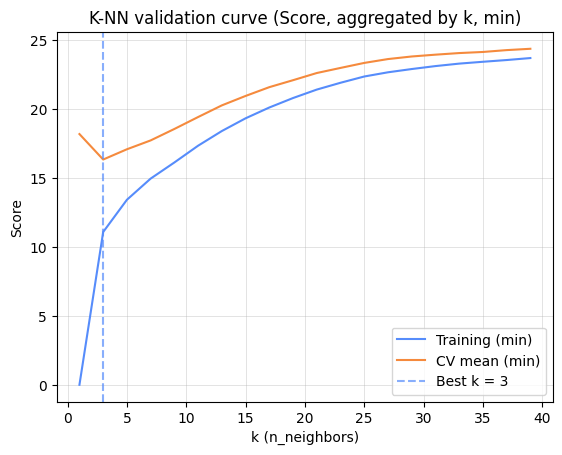

In [9]:
importlib.reload(kc)
kc.plot_knn_validation_curve_from_gs(gs,agg="min")

<h3>Learning Curve</h3>
<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>
<p>With distance-weighted KNN, the training error might be zero by construction, as each training point dominates its own prediction. Therefore, only the validation curve provides meaningful information about generalization.</p>

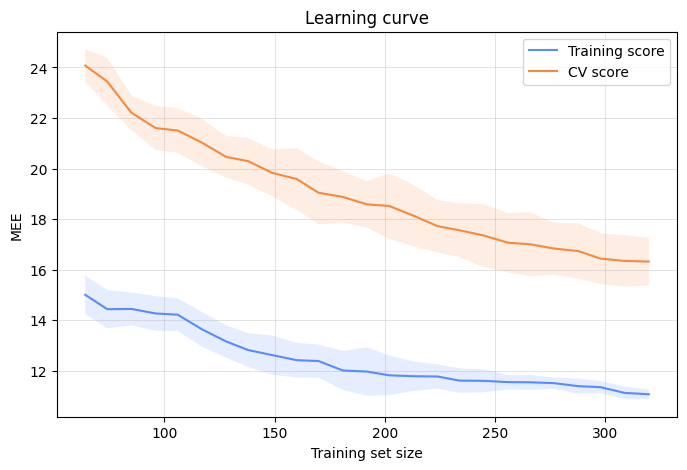

In [10]:
importlib.reload(cr)
cr.plot_learning_curve(best_estimator, X_tr, y_tr, outer_cv, scoring=grid_scoring)

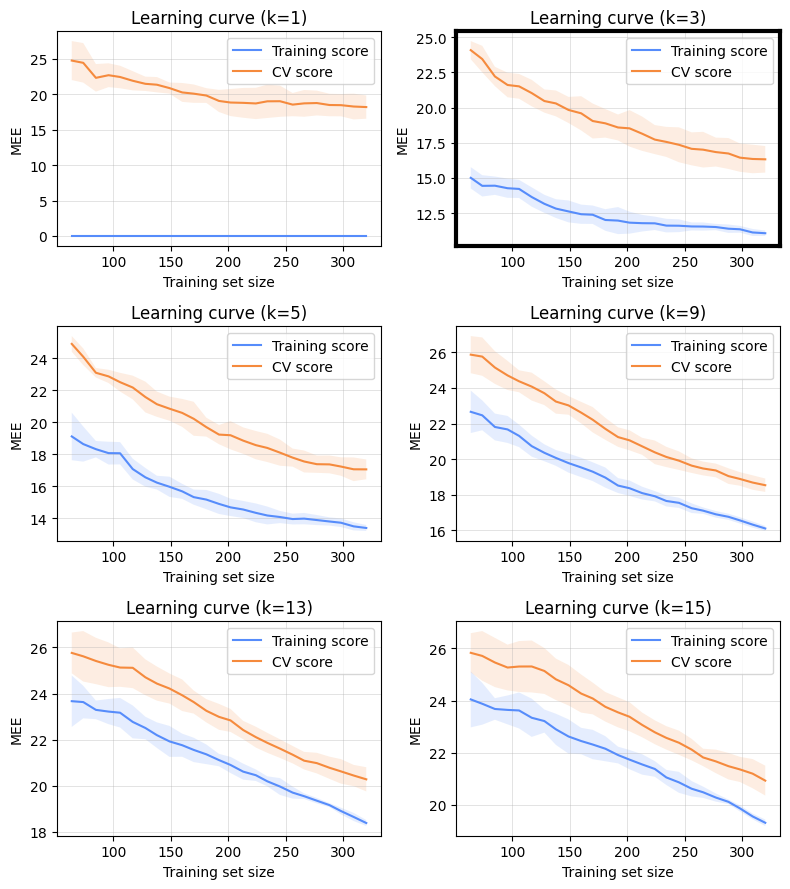

In [11]:
importlib.reload(kc)
kc.plot_knn_learning_curves_grid(
    best_estimator,
    X=X_tr,
    y=y_tr,
    cv=outer_cv,
    scoring=grid_scoring
)

<h2>Model estimation</h2>
<p>In order to display graphs and metrics, the model is rebuilt from scratch with parameters obtained from grid search, and it is then assessed trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [12]:
non_nested_runner = cr.SklearnRegressorRunner(gs)
non_nested_result = cr.kfold(non_nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 18.0120
Validation MSE       | 128.4657
Validation MAE       | 8.1770
Validation RMSE      | 11.3343
Validation R2        | 0.5644
Train                | samples: 320
Validation           | samples: 80
  
Perform fold: 2, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 15.9717
Validation MSE       | 92.7761
Validation MAE       | 7.0722
Validation RMSE      | 9.6320
Validation R2        | 0.6830
Train                | samples: 320
Validation           | samples: 80
  
Perform fold: 3, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 15.4871
Validation MSE       | 96.4608
Validation MAE       | 6.7389
Validation RMSE      |

<p>Comparing the metrics obtained from grid search with the one originating from kfold function. They must match almost exaclty apart from sign which depends on the scoring function.</p>

In [13]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(non_nested_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -16.3223 ± 0.9432
Best CV func score: 16.3223 ± 0.9432


<h3>Nested Cross Validation</h3>

In [14]:
importlib.reload(cr)

inner_cv = cr.common_fold_strategy(n_split=3)
outer_cv = outer_cv

gs_inner = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=grid_scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 320, val size: 80
Grid summary
----------------------------------------
Total model explored: 80  splits: 3
Best params: {'model__algorithm': 'auto', 'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'uniform', 'scaler': StandardScaler()}
Best score: -18.11598777770996
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsRegressor(n_neighbors=3))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 18.0120
Validation MSE       | 128.4657
Validation MAE       | 8.1770
Validation RMSE      | 11.3343
Validation R2        | 0.5644
Train                | samples: 320
Validation           | samples: 80
  
Perform fold: 2, train size: 320, val size: 80
Grid summary
----------------------------------------
Total model explored: 80  splits: 3
Best params: {'model__algorithm': 'auto', 'model__metric': 'minkowski', 'mode

<h3>Results</h3>

<p>We expect that non nested KFold result shows a more optimistic views (i.e. lower metrics) in respect to nested KFold.</p>

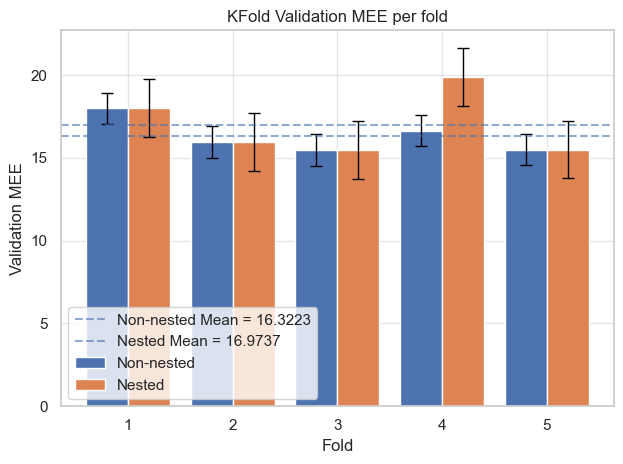

mee TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,10.791862,18.012014,7.220152
2,10.903291,15.971701,5.068410
3,11.304277,15.487109,4.182832
4,0.000000,19.895462,19.895462
5,11.156795,15.502319,4.345525
MEAN,8.831245,16.973721,8.142476
STD,4.419329,1.731687,5.975431


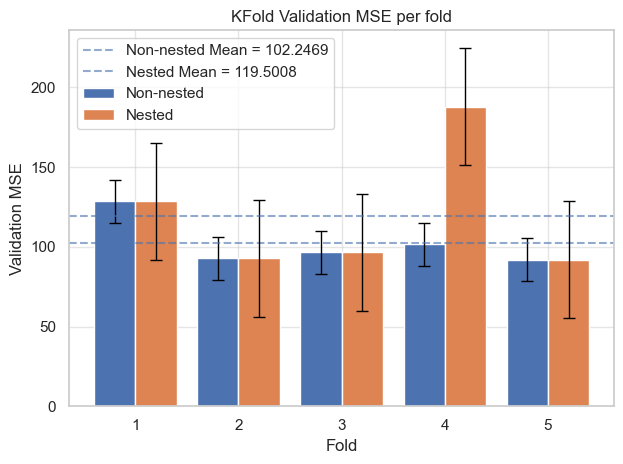

mse TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,47.166397,128.465668,81.299271
2,49.477341,92.776115,43.298775
3,50.850697,96.460800,45.610104
4,0.000000,187.810989,187.810989
5,50.209400,91.990341,41.780941
MEAN,39.540767,119.500783,79.960016
STD,19.809554,36.738336,55.884221


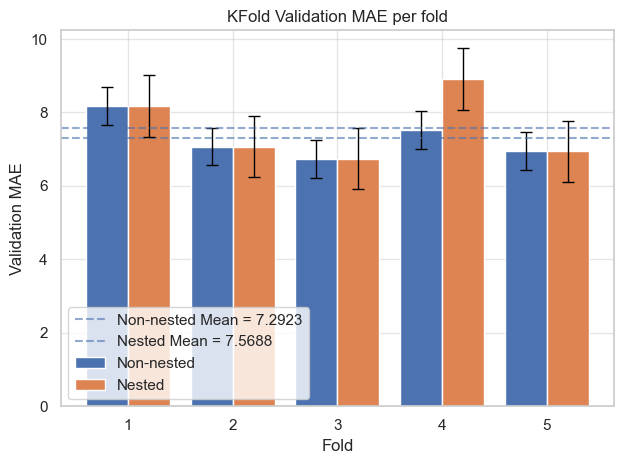

mae TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,4.813862,8.176984,3.363122
2,4.842039,7.072203,2.230164
3,5.091565,6.738903,1.647338
4,0.000000,8.911191,8.911191
5,5.024829,6.944583,1.919755
MEAN,3.954459,7.568773,3.614314
STD,1.980041,0.836288,2.712062


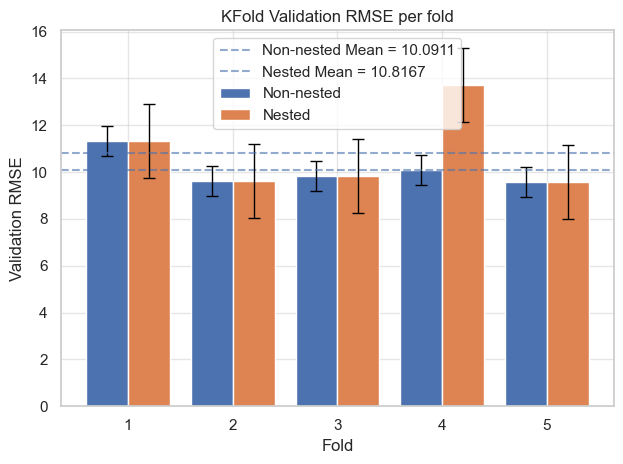

rmse TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,6.867780,11.334270,4.466490
2,7.034013,9.632036,2.598023
3,7.130967,9.821446,2.690478
4,0.000000,13.704415,13.704415
5,7.085859,9.591160,2.505300
MEAN,5.623724,10.816665,5.192941
STD,2.813272,1.581309,4.317227


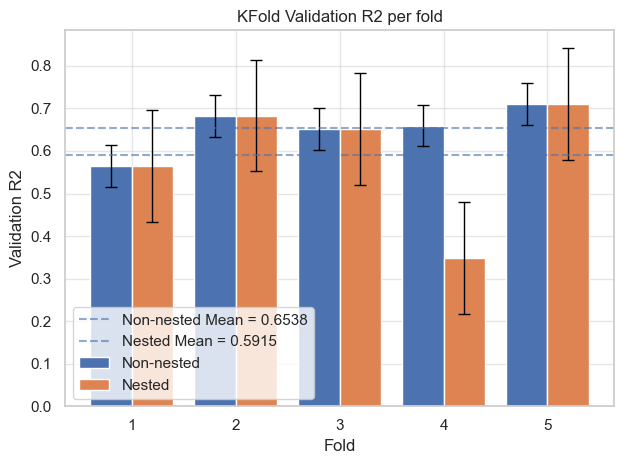

r2 TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.844942,0.564386,-0.280556
2,0.835809,0.682985,-0.152824
3,0.836166,0.651750,-0.184416
4,1.000000,0.348141,-0.651859
5,0.829265,0.710090,-0.119175
MEAN,0.869236,0.591470,-0.277766
STD,0.065572,0.131165,0.194643


In [15]:
importlib.reload(cr)
for metric in the_metrics:
    cr.plot_kfold_metric([(non_nested_result,"Non-nested"), (nested_result, "Nested")], metric)
    print(f"{metric} TR vs VL from KFold Nested results")
    display(cr.kfold_summary(nested_result, use=metric))

<h3>Bootstrap Variance</h3>
<p>Bootstrap is applied to approximate the sampling distribution of the estimator when only a finite dataset is available. By generating multiple resampled datasets, we can estimate variance, assess model stability, and better understand generalization behavior.</p>

In [16]:
importlib.reload(cr)
bootstrap_samples = 100
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
bootstrap_params = {"silence_output": True, "model_type":"regression"}
bootstrap_scores = cr.bootstrap_out_of_bag_scores(non_nested_runner, X_tr, y_tr, samples, metrics_fn=metrics_dict, bootstrap_params=bootstrap_params)

In [17]:
cr.aggregate_scores(bootstrap_scores)


,Metric,Mean,Std,%
0,MSE,125.58,15.95,12.70
1,MAE,7.86,0.49,6.25
2,MEE,17.66,1.09,6.16
3,R2,0.58,0.04,7.65
4,RMSE,11.18,0.71,6.33


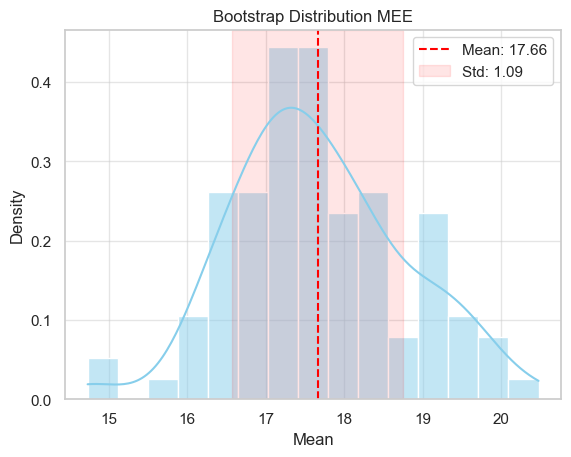

In [18]:
importlib.reload(cr)
cr.plot_bootstrap_distribution([metric[default_metric] for metric in bootstrap_scores], title=f"Bootstrap Distribution {default_metric.upper()}")

<h2>Internal Test predictions</h2>
<hr/>

In [19]:
fitted_model = non_nested_runner.fitted_model(X_tr, y_tr)

y_pred_tr = non_nested_runner.predict(fitted_model, X_tr)
y_pred_internal = non_nested_runner.predict(
    fitted_model,
    X_internal_ts,
)

mee_tr = cr.mee(y_tr, y_pred_tr)
mee_internal = cr.mee(y_internal_ts, y_pred_internal)

print(f"Training MEE:      {mee_tr:.4f}")
print(f"Internal Test MEE: {mee_internal:.4f}")


Training MEE:      10.5313
Internal Test MEE: 16.8191


<hr/>